# Implementacão - Dask

## Detalhes

1. Gestão de Dados
- Dask não herda variáveis globais via Copy-on-Write (fork) da mesma forma transparente que o *multiprocessing*.
- É necessário utilizar *client.scatter* para enviar as matrizes aos workers de forma eficiente.

## Dashboard

- O Dask oferece um dashboard web (porta 8787) para visualizar o uso de CPU/Memória em tempo real.
- Dashboard: http://127.0.0.1:8787
- Dependência:

```bash
pip install "bokeh!=3.0.*,>=2.4.2" --proxy "http://proxy.tjrs.gov.br:8080"
```



## Confirmação de versão do Python em uso

In [3]:
import sys
print(sys.version_info)

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)


In [8]:
import psutil
import getpass
import os
import sys
import time
import numpy as np
import pandas as pd
from datetime import datetime
from dask.distributed import Client, LocalCluster

# --------------------------------------
# CONFIGURATION
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

MATRIX_SIZE = 2000
CPU_SETS = {
    "1-T": [0],
    "2-T": [0, 2],
    "2-T-HP": [0, 1],
    "4-T": [0, 2, 4, 6],
    "4-T-HP": [0, 1, 2, 3],
    "8-T": [0, 2, 4, 6, 8, 10, 12, 14],
    "8-T-HP": [0, 1, 2, 3, 4, 5, 6, 7],
}
NUM_RUNS = 2
GOVERNOR = "performance"
IDLE_TIME = 1

# --------------------------------------
# Helper Functions (Governor & Safety)
def safety_check(cpu_ids):
    if MATRIX_SIZE % len(cpu_ids) != 0:
        print(f"Error: MATRIX_SIZE ({MATRIX_SIZE}) not divisible by workers ({len(cpu_ids)}).")
        sys.exit(1)

def set_governor(governor: str):
    # (Mantido igual ao original - omitido para brevidade, mas deve estar aqui)
    pass 

def get_governor(cpu_id):
    path = f"/sys/devices/system/cpu/cpu{cpu_id}/cpufreq/scaling_governor"
    try:
        with open(path) as f: return f.read().strip()
    except FileNotFoundError: return "N/A"

# --------------------------------------
# Worker Task Adaptada para Dask
def worker_task_dask(args):
    """
    Recebe os dados explicitamente (A e B são referências scatter do Dask).
    """
    row_index, chunk_size, cpu_ids, A_matrix, B_matrix = args
    
    # Identificação rudimentar do worker baseada no chunk (assumindo ordem)
    # Em Dask, isso é menos determinístico, mas funciona se tasks == workers
    worker_id = row_index // chunk_size 
    target_cpu = cpu_ids[worker_id % len(cpu_ids)]

    # Define afinidade
    p = psutil.Process(os.getpid())
    p.cpu_affinity([target_cpu])

    # Fatia a matriz A localmente
    start_row = row_index
    end_row = row_index + chunk_size
    A_chunk = A_matrix[start_row:end_row, :]

    # Cálculo
    return np.dot(A_chunk, B_matrix)

# --------------------------------------
# Main Execution
if __name__ == "__main__":
    # print("Passo 1: Configurar governor")
    # set_governor(GOVERNOR) # Descomente se tiver permissões sudo

    results = []
    print("Passo 2: Execuções com Dask")

    for run in range(1, NUM_RUNS + 1):
        for label, cores in CPU_SETS.items():
            safety_check(cores)
            governor = get_governor(cores[0])

            # Gerar dados (Numpy normal)
            A_host = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)
            B_host = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)

            chunk_size = MATRIX_SIZE // len(cores)

            # -------------------------------------------------------
            # INÍCIO DO BLOCO DASK
            # Criamos um cluster local efêmero para simular o Pool
            # threads_per_worker=1 garante que é multiprocesso puro, não multithread
            # -------------------------------------------------------
            with LocalCluster(n_workers=len(cores), 
                              threads_per_worker=1, 
                              processes=True,
                              silence_logs=40) as cluster:
                
                with Client(cluster) as client:
                    start_time = time.time()

                    # 1. SCATTER: Enviar dados para a memória dos workers
                    # Isso substitui a herança de memória global do fork()
                    # broadcast=True envia para todos os workers antecipadamente
                    A_future = client.scatter(A_host, broadcast=True)
                    B_future = client.scatter(B_host, broadcast=True)

                    # 2. PREPARAR TASKS
                    # Passamos os futures (A_future, B_future) ao invés dos dados crus
                    tasks_args = []
                    for i in range(len(cores)):
                        args = (i * chunk_size, chunk_size, cores, A_future, B_future)
                        tasks_args.append(args)

                    # 3. SUBMIT & GATHER
                    # map envia as tarefas e retorna futures
                    futures = client.map(worker_task_dask, tasks_args)
                    
                    # gather bloqueia até terminar e traz os resultados
                    C_chunks = client.gather(futures)
                    
                    # 4. COMBINAR
                    C = np.vstack(C_chunks)
                    
                    end_time = time.time()
            # -------------------------------------------------------

            total_time = end_time - start_time
            
            results.append({
                "Run": run, "Scenario": label, "CPUs_used": cores,
                "Governor": governor, "Time_sec": total_time, "Result_shape": C.shape
            })
            print(f"Run {run} | {label}: {cores} | Time: {total_time:.4f}s")
            time.sleep(IDLE_TIME)

    df_results = pd.DataFrame(results)
    print("\nResumo Dask:\n", df_results[["Run", "Scenario", "Time_sec"]].sort_values(by="Scenario"))
    
    # cria dataframe com todos os resultados
    df_results = pd.DataFrame(results)
    pd.set_option('display.width', 1000) # Evita quebra de linha do print do df  
    df_reduced = df_results[["Run", "Scenario", "Governor", "Time_sec"]]
    df_sorted = df_reduced.sort_values(by="Scenario", ascending=False)
    print("\nResumo em DataFrame:\n", df_sorted)
    
    # salvar em CSV
    now = datetime.now()
    data_str = now.strftime("%Y%m%d") # formato aaaammdd
    hora_str = now.strftime("%H%M%S") # formato hhmmss
    filename = (
    f"{data_str}_{hora_str}_matrix{MATRIX_SIZE}_"
        f"numruns{NUM_RUNS}_{GOVERNOR}.csv"
    )
    df_results.to_csv(filename, index=False)
    print(f"\nResultados salvos em: {filename}") 
    
    

Passo 2: Execuções com Dask
Run 1 | 1-T: [0] | Time: 3.2955s
Run 1 | 2-T: [0, 2] | Time: 1.9258s
Run 1 | 2-T-HP: [0, 1] | Time: 2.0427s
Run 1 | 4-T: [0, 2, 4, 6] | Time: 1.6797s
Run 1 | 4-T-HP: [0, 1, 2, 3] | Time: 1.6931s
Run 1 | 8-T: [0, 2, 4, 6, 8, 10, 12, 14] | Time: 1.6045s
Run 1 | 8-T-HP: [0, 1, 2, 3, 4, 5, 6, 7] | Time: 1.5662s
Run 2 | 1-T: [0] | Time: 3.0996s
Run 2 | 2-T: [0, 2] | Time: 1.9892s
Run 2 | 2-T-HP: [0, 1] | Time: 2.0709s
Run 2 | 4-T: [0, 2, 4, 6] | Time: 1.6637s
Run 2 | 4-T-HP: [0, 1, 2, 3] | Time: 1.6530s
Run 2 | 8-T: [0, 2, 4, 6, 8, 10, 12, 14] | Time: 1.5531s
Run 2 | 8-T-HP: [0, 1, 2, 3, 4, 5, 6, 7] | Time: 1.6407s

Resumo Dask:
     Run Scenario  Time_sec
0     1      1-T  3.295539
7     2      1-T  3.099554
1     1      2-T  1.925826
8     2      2-T  1.989163
2     1   2-T-HP  2.042700
9     2   2-T-HP  2.070929
3     1      4-T  1.679679
10    2      4-T  1.663750
4     1   4-T-HP  1.693082
11    2   4-T-HP  1.652978
5     1      8-T  1.604495
12    2      8-

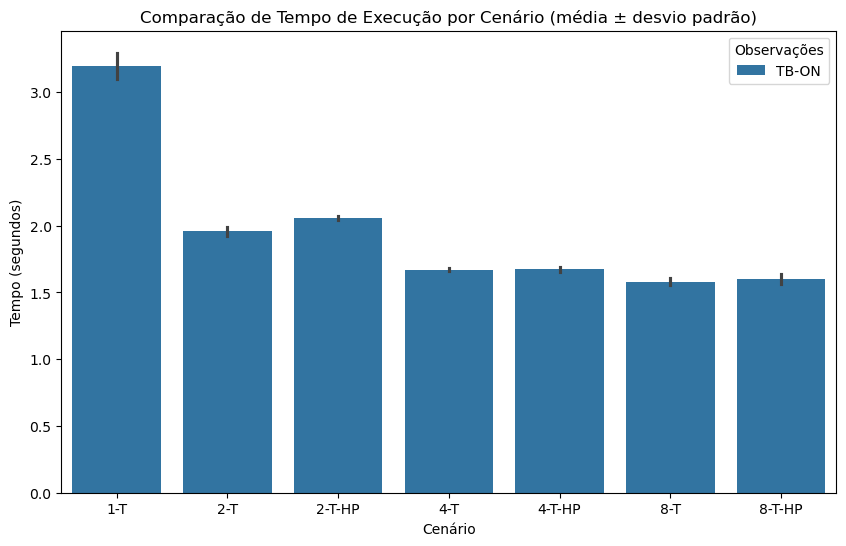

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Supondo que seus arquivos estejam em CSV
df1 = pd.read_csv('20251116_214047_matrix2000_numruns2_performance.csv') # Com Turbo Bost
#df2 = pd.read_csv('20251111_170848_matrix1000_numruns5_performance.csv') 

df1['Dataset'] = 'TB-ON'
#df2['Dataset'] = '-'

#df_combined = pd.concat([df1, df2], ignore_index=True)

plt.figure(figsize=(10,6))
#sns.barplot(x='Scenario', y='Time_sec', hue='Dataset', data=df_combined, ci='sd')
sns.barplot(
    x='Scenario',
    y='Time_sec',
    hue='Dataset',
    data=df1,
    estimator='mean'       # calcula a média automaticamente
    #errorbar='sd'           # mostra desvio padrão
)
plt.title('Comparação de Tempo de Execução por Cenário (média ± desvio padrão)')
plt.ylabel('Tempo (segundos)')
plt.xlabel('Cenário')
plt.legend(title='Observações')

# Salvar como PDF
#plt.savefig('grafico_time_sec.pdf', format='pdf', bbox_inches='tight')

# Salvar como PNG
plt.savefig('grafico_time_sec.png', format='png', dpi=300, bbox_inches='tight')

plt.show()